<a href="https://colab.research.google.com/github/fraycarmona/eml_tabular_grupo_17/blob/ADRIAN/src/EntornosComplejos/estudiosarsa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio SARSA semi-gradiente (Pendulum-v1)

Entrenamiento reproducible con semilla fija `SEED=2024`.

In [1]:
!git clone -b ADRIAN https://github.com/fraycarmona/eml_tabular_grupo_17
%cd eml_tabular_grupo_17/src/EntornosComplejos


Cloning into 'eml_tabular_grupo_17'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 128 (delta 48), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 1.96 MiB | 6.59 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/eml_tabular_grupo_17/src/EntornosComplejos


In [2]:
SEED = 2024
import random
import numpy as np
import torch
import gymnasium as gym

from agents.pendulumsarsaagent import PendulumSarsaAgent
from plotting.plotting import plotlearningcurve, plotlosscurve

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [3]:
env = gym.make('Pendulum-v1')
agent = PendulumSarsaAgent(env=env, seed=SEED)
history_sarsa = agent.train(num_episodes=200, max_steps=200)


In [4]:
def random_baseline(env_name='Pendulum-v1', episodes=500, max_steps=200, seed=SEED):
    env_r = gym.make(env_name)
    rewards, lengths = [], []
    for ep in range(episodes):
        state, _ = env_r.reset(seed=seed + ep)
        total = 0.0
        for t in range(1, max_steps + 1):
            action = env_r.action_space.sample()
            state, r, terminated, truncated, _ = env_r.step(action)
            total += r
            if terminated or truncated:
                break
        rewards.append(total)
        lengths.append(t)
    env_r.close()
    return {'rewards': rewards, 'lengths': lengths}

baseline = random_baseline()


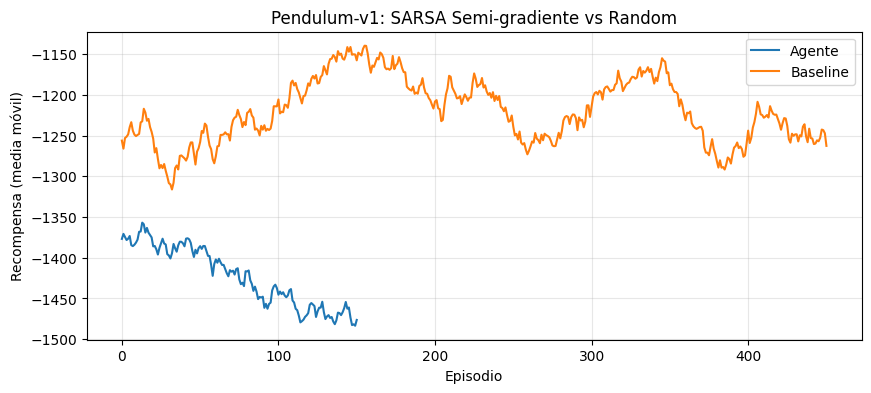

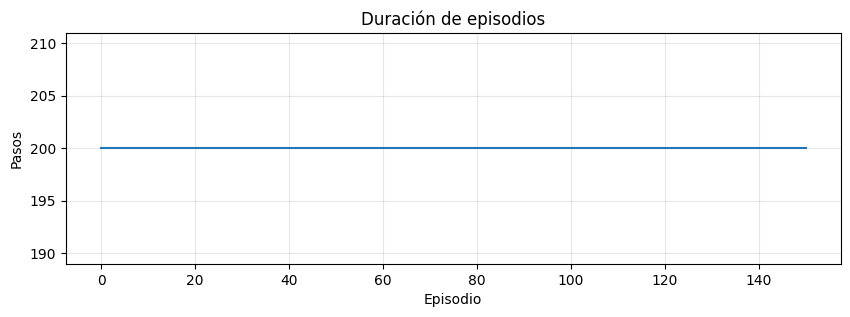

In [5]:
plotlearningcurve(
    rewardshistory=history_sarsa['rewards'],
    baselinehistory=baseline['rewards'],
    episode_length_history=history_sarsa['lengths'],
    window=50,
    title='Pendulum-v1: SARSA Semi-gradiente vs Random'
)


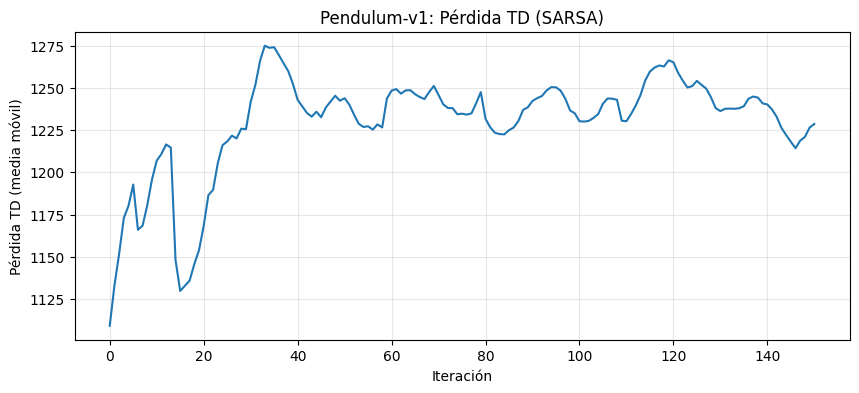

In [6]:
plotlosscurve(
    losshistory=history_sarsa['losses'],
    window=50,
    title='Pendulum-v1: Pérdida TD (SARSA)'
)


In [7]:
print('Recompensa media final SARSA (100 últimos episodios):', np.mean(history_sarsa['rewards'][-100:]))
print('Recompensa media baseline:', np.mean(baseline['rewards']))


Recompensa media final SARSA (100 últimos episodios): -1460.8441932524304
Recompensa media baseline: -1223.3554336452553
